# Mamion Miam — Analyses
MongoDB + Neo4J + Matplotlib inline

In [23]:
%matplotlib inline
import os, sys
from collections import Counter
import matplotlib.pyplot as plt
import pandas as pd
from pymongo import MongoClient
from neo4j import GraphDatabase
from tabulate import tabulate
from datetime import date

sys.path.insert(0, os.path.abspath('.'))
from config import MONGO_URI, MONGO_DB, NEO4J_URI, NEO4J_USER, NEO4J_PASSWORD

mongo  = MongoClient(MONGO_URI)
db     = mongo[MONGO_DB]
driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))

def cypher(query, **params):
    with driver.session() as s:
        return [dict(r) for r in s.run(query, **params)]

print('Connexions OK')

Connexions OK


## Analyse des ventes

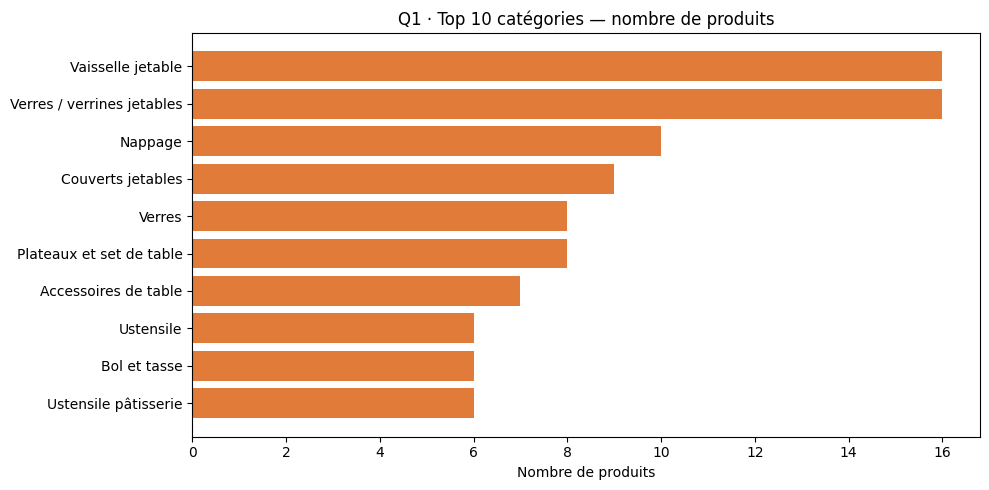

In [24]:
# Q1 — Top 10 catégories par nombre de produits
rows = list(db.produits.aggregate([
    {'$group': {'_id': '$Categorie', 'nb': {'$sum': 1}}},
    {'$sort':  {'nb': -1}},
    {'$limit': 10}
]))
df = pd.DataFrame(rows).rename(columns={'_id': 'categorie'})

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(df['categorie'][::-1], df['nb'][::-1], color='#e07b39')
ax.set_xlabel('Nombre de produits')
ax.set_title('Q1 · Top 10 catégories — nombre de produits')
plt.tight_layout()
plt.savefig('exports/q1_top_categories_produits.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
# Q2 — Top rayons par nombre de catégories
rows = list(db.produits.aggregate([
    {'$group': {'_id': '$Rayon', 'cats': {'$addToSet': '$Categorie'}}},
    {'$project': {'nb_categories': {'$size': '$cats'}}},
    {'$sort': {'nb_categories': -1}}
]))
print(tabulate([(r['_id'], r['nb_categories']) for r in rows],
               headers=['Rayon', 'Nb catégories'], tablefmt='pipe'))

| Rayon            |   Nb catégories |
|:-----------------|----------------:|
| Arts de la table |              11 |
| Cuisine cuisson  |               8 |
| Ménage           |               6 |
| Puériculture     |               1 |


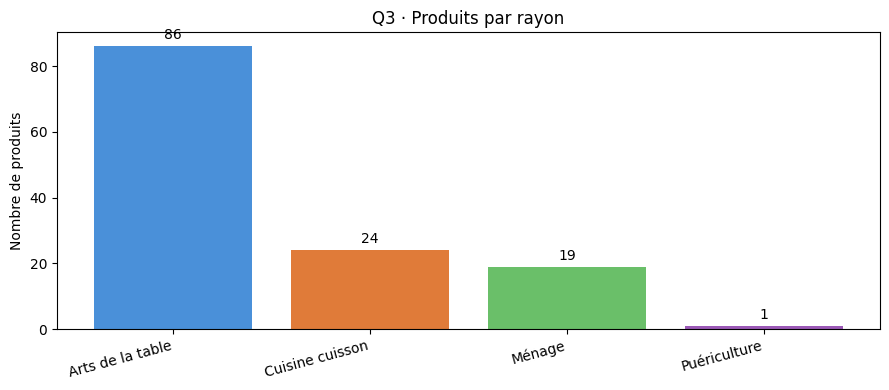

In [26]:
# Q3 — Top rayons par nombre de produits
rows = list(db.produits.aggregate([
    {'$group': {'_id': '$Rayon', 'nb': {'$sum': 1}}},
    {'$sort':  {'nb': -1}}
]))
df = pd.DataFrame(rows).rename(columns={'_id': 'rayon'})

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(df['rayon'], df['nb'], color=['#4a90d9', '#e07b39', '#6abf69', '#9b59b6'])
ax.bar_label(bars, padding=3)
ax.set_ylabel('Nombre de produits')
ax.set_title('Q3 · Produits par rayon')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('exports/q3_produits_par_rayon.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
# Q4 — Paires de produits achetés ensemble
tickets = list(db.achats.aggregate([{'$project': {'skus': '$detail.SKU'}}]))
paires = Counter()
for t in tickets:
    skus = sorted(set(t.get('skus', [])))
    for i in range(len(skus)):
        for j in range(i + 1, len(skus)):
            paires[(skus[i], skus[j])] += 1

sku_to_label = {p['SKU']: p['Label'] for p in db.produits.find({}, {'SKU': 1, 'Label': 1, '_id': 0})}
top10 = [([sku_to_label.get(a, a)[:35], sku_to_label.get(b, b)[:35], n]) for (a, b), n in paires.most_common(10)]
print(tabulate(top10, headers=['Produit A', 'Produit B', 'Co-occurrences'], tablefmt='pipe'))

| Produit A                           | Produit B                           |   Co-occurrences |
|:------------------------------------|:------------------------------------|-----------------:|
| Lot de 6 Gobelets en Papier "1 An d | Range couverts vert                 |                4 |
| Brosse à Vaisselle Effet Marbre "Sc | Nappe Toile cirée au mètre Jalna    |                3 |
| Verre à pied 58 cl Grand Chais Wine | Assiette pulpe carrée blanche x 24  |                3 |
| Lot de 20 Assiettes en Carton "Vita | Nappe Toile cirée au mètre Lamas ro |                3 |
| Presse Agrumes "Emboitable" 16cm Tr | Lot de 20 Assiettes en Carton "Vita |                3 |
| Boîte de conservation carrée hermét | VERRE PETRUS 33CL                   |                3 |
| Tasse cuivre 9 cl Conserve Moi      | Egouttoir à vaisselle avec plateau  |                3 |
| Tapis Vaisselle "Absorbant" 35x45cm | Douille à pâtisserie en inox - Gran |                3 |
| Set de Table Ajouré "Créole"

In [28]:
# Q5 — Catégories avec le plus de lignes de vente
rows = list(db.achats.aggregate([
    {'$unwind': '$detail'},
    {'$lookup': {'from': 'produits', 'localField': 'detail.SKU', 'foreignField': 'SKU', 'as': 'prod'}},
    {'$unwind': {'path': '$prod', 'preserveNullAndEmptyArrays': True}},
    {'$group': {'_id': '$prod.Categorie', 'nb_lignes': {'$sum': 1}}},
    {'$sort': {'nb_lignes': -1}}, {'$limit': 10}
]))
print(tabulate([(r['_id'] or '?', r['nb_lignes']) for r in rows],
               headers=['Catégorie', 'Lignes de vente'], tablefmt='pipe'))

| Catégorie                  |   Lignes de vente |
|:---------------------------|------------------:|
| Vaisselle jetable          |               344 |
| Verres / verrines jetables |               334 |
| Nappage                    |               197 |
| Couverts jetables          |               175 |
| Accessoires de table       |               159 |
| Verres                     |               152 |
| Plateaux et set de table   |               147 |
| Bol et tasse               |               145 |
| Lavage                     |               124 |
| Ustensile pâtisserie       |               124 |


In [29]:
# Q6 — Catégories avec le plus de quantité vendue
rows = list(db.achats.aggregate([
    {'$unwind': '$detail'},
    {'$lookup': {'from': 'produits', 'localField': 'detail.SKU', 'foreignField': 'SKU', 'as': 'prod'}},
    {'$unwind': {'path': '$prod', 'preserveNullAndEmptyArrays': True}},
    {'$group': {'_id': '$prod.Categorie', 'qte_totale': {'$sum': '$detail.qte'}}},
    {'$sort': {'qte_totale': -1}}, {'$limit': 10}
]))
print(tabulate([(r['_id'] or '?', r['qte_totale']) for r in rows],
               headers=['Catégorie', 'Quantité vendue'], tablefmt='pipe'))

| Catégorie                  |   Quantité vendue |
|:---------------------------|------------------:|
| Vaisselle jetable          |               633 |
| Verres / verrines jetables |               621 |
| Nappage                    |               362 |
| Couverts jetables          |               329 |
| Accessoires de table       |               286 |
| Verres                     |               284 |
| Plateaux et set de table   |               274 |
| Bol et tasse               |               263 |
| Ustensile                  |               240 |
| Ustensile pâtisserie       |               239 |


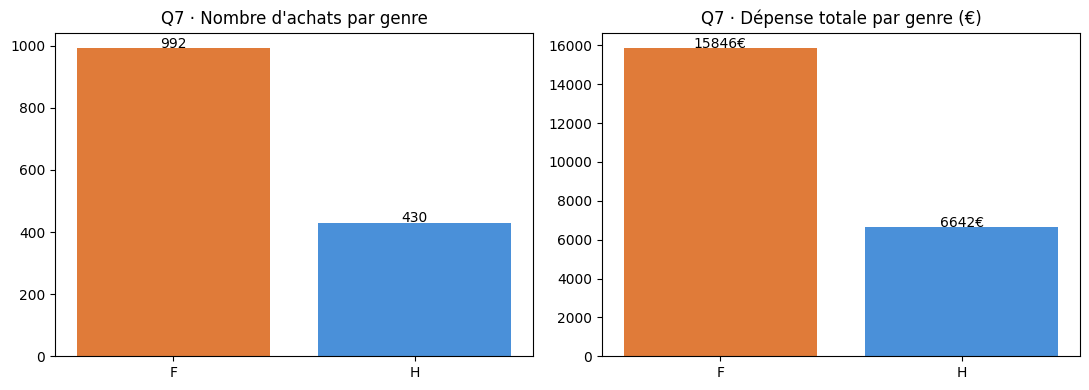

In [30]:
# Q7 — Achats et dépense par genre
rows = list(db.achats.aggregate([
    {'$lookup': {'from': 'clients', 'localField': 'acheteur', 'foreignField': 'id', 'as': 'client'}},
    {'$unwind': {'path': '$client', 'preserveNullAndEmptyArrays': True}},
    {'$group': {'_id': '$client.genre', 'nb_achats': {'$sum': 1}, 'depense_totale': {'$sum': '$total'}}},
    {'$sort': {'_id': 1}}
]))
df = pd.DataFrame(rows).rename(columns={'_id': 'genre'}).fillna({'genre': '?'})
colors = [{'F': '#e07b39', 'H': '#4a90d9'}.get(g, '#aaa') for g in df['genre']]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(df['genre'], df['nb_achats'], color=colors)
axes[0].set_title("Q7 · Nombre d'achats par genre")
for i, v in enumerate(df['nb_achats']):
    axes[0].text(i, v + 2, str(v), ha='center')
axes[1].bar(df['genre'], df['depense_totale'], color=colors)
axes[1].set_title('Q7 · Dépense totale par genre (€)')
for i, v in enumerate(df['depense_totale']):
    axes[1].text(i, v + 20, f'{v:.0f}€', ha='center')
plt.tight_layout()
plt.savefig('exports/q7_achats_par_genre.png', dpi=150, bbox_inches='tight')
plt.show()

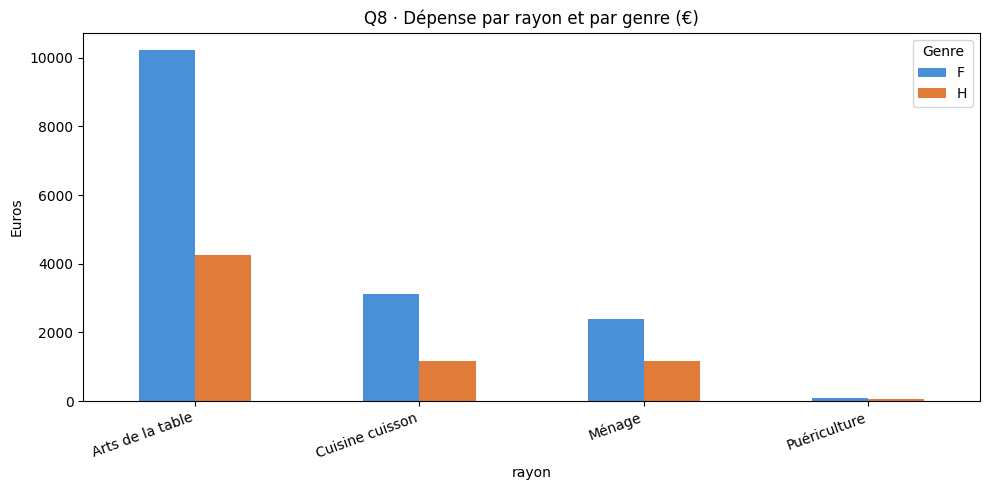

In [31]:
# Q8 — Dépense par genre et par rayon
rows = list(db.achats.aggregate([
    {'$unwind': '$detail'},
    {'$lookup': {'from': 'clients', 'localField': 'acheteur', 'foreignField': 'id', 'as': 'client'}},
    {'$unwind': {'path': '$client', 'preserveNullAndEmptyArrays': True}},
    {'$lookup': {'from': 'produits', 'localField': 'detail.SKU', 'foreignField': 'SKU', 'as': 'prod'}},
    {'$unwind': {'path': '$prod', 'preserveNullAndEmptyArrays': True}},
    {'$group': {'_id': {'genre': '$client.genre', 'rayon': '$prod.Rayon'}, 'depense': {'$sum': '$detail.total'}}},
    {'$sort': {'_id.rayon': 1}}
]))
df = pd.DataFrame([{'genre': r['_id'].get('genre') or '?', 'rayon': r['_id'].get('rayon') or '?',
                    'depense': round(r['depense'], 2)} for r in rows])
pivot = df.pivot_table(index='rayon', columns='genre', values='depense', aggfunc='sum').fillna(0)
pivot.plot(kind='bar', figsize=(10, 5), color=['#4a90d9', '#e07b39'])
plt.title('Q8 · Dépense par rayon et par genre (€)')
plt.ylabel('Euros')
plt.xticks(rotation=20, ha='right')
plt.legend(title='Genre')
plt.tight_layout()
plt.savefig('exports/q8_depense_rayon_genre.png', dpi=150, bbox_inches='tight')
plt.show()

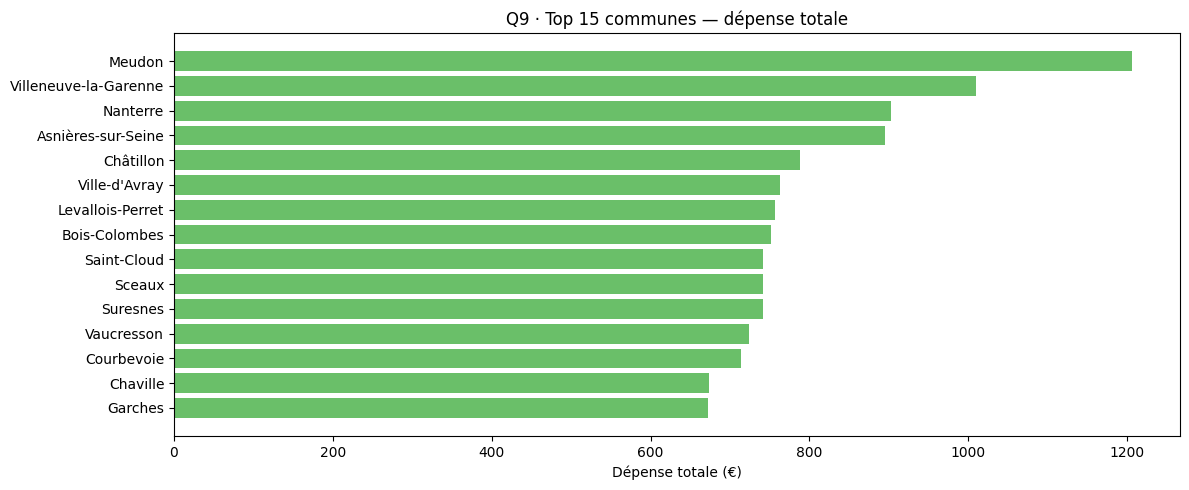

In [32]:
# Q9 — Top 15 communes par dépense
rows = list(db.achats.aggregate([
    {'$lookup': {'from': 'clients', 'localField': 'acheteur', 'foreignField': 'id', 'as': 'client'}},
    {'$unwind': {'path': '$client', 'preserveNullAndEmptyArrays': True}},
    {'$group': {'_id': '$client.commune', 'nb_achats': {'$sum': 1}, 'depense_totale': {'$sum': '$total'}}},
    {'$sort': {'depense_totale': -1}}, {'$limit': 15}
]))
df = pd.DataFrame(rows).rename(columns={'_id': 'commune'}).fillna({'commune': '?'})

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(df['commune'][::-1], df['depense_totale'][::-1], color='#6abf69')
ax.set_xlabel('Dépense totale (€)')
ax.set_title('Q9 · Top 15 communes — dépense totale')
plt.tight_layout()
plt.savefig('exports/q9_depense_par_commune.png', dpi=150, bbox_inches='tight')
plt.show()

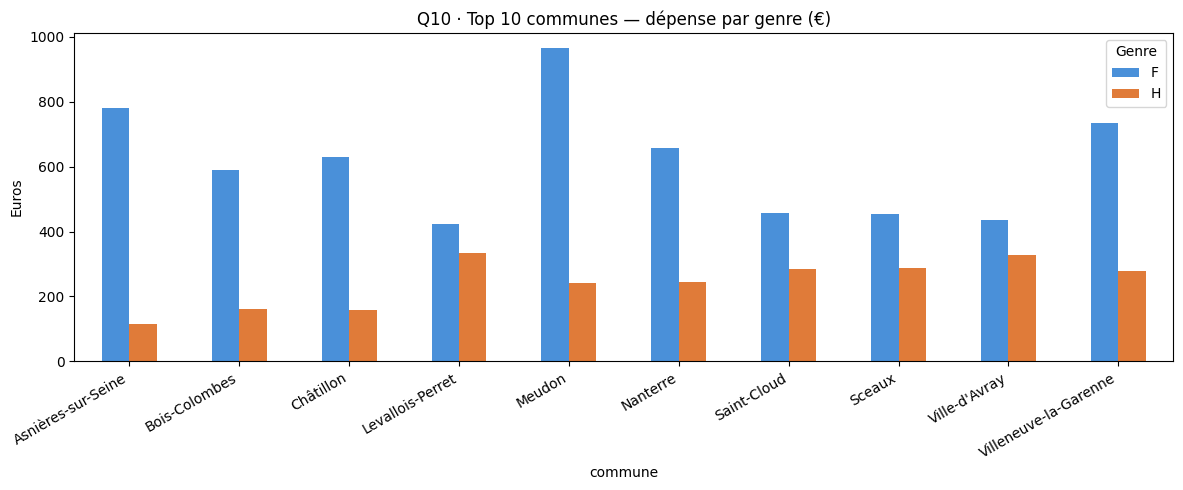

In [33]:
# Q10 — Dépense par commune et par genre (top 10)
rows = list(db.achats.aggregate([
    {'$lookup': {'from': 'clients', 'localField': 'acheteur', 'foreignField': 'id', 'as': 'client'}},
    {'$unwind': {'path': '$client', 'preserveNullAndEmptyArrays': True}},
    {'$group': {'_id': {'commune': '$client.commune', 'genre': '$client.genre'}, 'depense_totale': {'$sum': '$total'}}}
]))
df = pd.DataFrame([{'commune': r['_id'].get('commune') or '?', 'genre': r['_id'].get('genre') or '?',
                    'depense': round(r['depense_totale'], 2)} for r in rows])
top_communes = df.groupby('commune')['depense'].sum().nlargest(10).index
pivot = df[df['commune'].isin(top_communes)].pivot_table(index='commune', columns='genre', values='depense', aggfunc='sum').fillna(0)
pivot.plot(kind='bar', figsize=(12, 5), color=['#4a90d9', '#e07b39'])
plt.title('Q10 · Top 10 communes — dépense par genre (€)')
plt.ylabel('Euros')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Genre')
plt.tight_layout()
plt.savefig('exports/q10_depense_commune_genre.png', dpi=150, bbox_inches='tight')
plt.show()

## Analyse du parrainage

In [34]:
# Q1 — Top parrain et ses filleuls
rows = cypher("""
    MATCH (p:Usr)-[:SPONSORED]->(f:Usr)
    WITH p, count(f) AS nb ORDER BY nb DESC LIMIT 1
    MATCH (p)-[:SPONSORED]->(filleul:Usr)
    RETURN p.id AS parrain_id, p.prenom AS prenom, p.nom AS nom, nb AS nb_filleuls,
           filleul.id AS filleul_id, filleul.prenom AS filleul_prenom, filleul.nom AS filleul_nom
""")
if rows:
    r = rows[0]
    print(f"Parrain : {r['prenom']} {r['nom']} — {r['nb_filleuls']} filleuls")
    filleuls = [{'id': x['filleul_id'], 'prenom': x['filleul_prenom'], 'nom': x['filleul_nom']} for x in rows]
    print(tabulate(filleuls, headers='keys', tablefmt='pipe'))

Parrain : Marthe Roux — 5 filleuls
|   id | prenom    | nom      |
|-----:|:----------|:---------|
|   94 | Patrick   | Sanchez  |
|   56 | Brigitte  | Le Roux  |
|  151 | Corinne   | Aubry    |
|   93 | Élodie    | Vincent  |
|   95 | Christine | Thibault |


In [35]:
# Q2 — H/F parrains et filleuls
print('Parrains :')
print(tabulate(cypher('MATCH (p:Usr)-[:SPONSORED]->() RETURN p.genre AS genre, count(DISTINCT p) AS nb ORDER BY genre'),
               headers='keys', tablefmt='pipe'))
print('\nFilleuls :')
print(tabulate(cypher('MATCH ()-[:SPONSORED]->(f:Usr) RETURN f.genre AS genre, count(DISTINCT f) AS nb ORDER BY genre'),
               headers='keys', tablefmt='pipe'))

Parrains :
| genre   |   nb |
|:--------|-----:|
| F       |  277 |
| H       |  107 |

Filleuls :
| genre   |   nb |
|:--------|-----:|
| F       |  376 |
| H       |  170 |


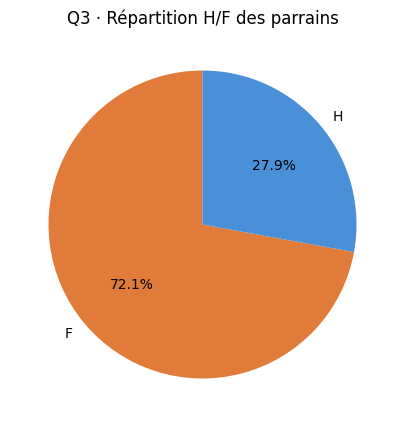

In [36]:
# Q3 — Répartition H/F des parrains
rows = cypher('MATCH (p:Usr)-[:SPONSORED]->() RETURN p.genre AS genre, count(DISTINCT p) AS nb')
df = pd.DataFrame(rows).fillna({'genre': '?'})
fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(df['nb'], labels=df['genre'], autopct='%1.1f%%',
       colors=['#e07b39', '#4a90d9'], startangle=90)
ax.set_title('Q3 · Répartition H/F des parrains')
plt.savefig('exports/q3_hf_parrains.png', dpi=150, bbox_inches='tight')
plt.show()

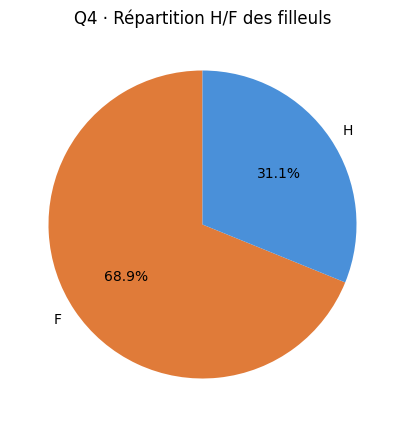

In [37]:
# Q4 — Répartition H/F des filleuls
rows = cypher('MATCH ()-[:SPONSORED]->(f:Usr) RETURN f.genre AS genre, count(DISTINCT f) AS nb')
df = pd.DataFrame(rows).fillna({'genre': '?'})
fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(df['nb'], labels=df['genre'], autopct='%1.1f%%',
       colors=['#e07b39', '#4a90d9'], startangle=90)
ax.set_title('Q4 · Répartition H/F des filleuls')
plt.savefig('exports/q4_hf_filleuls.png', dpi=150, bbox_inches='tight')
plt.show()

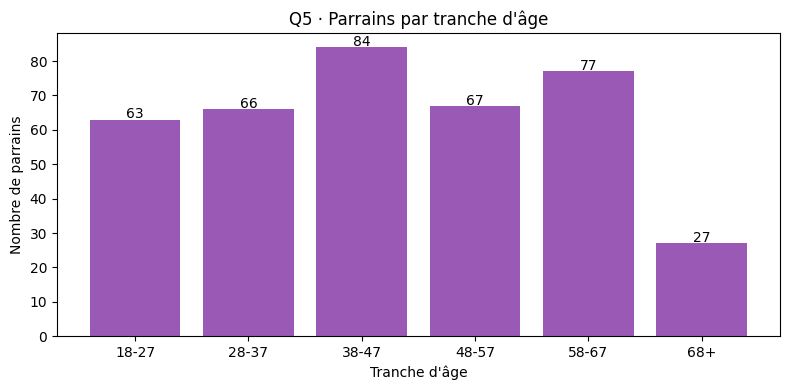

In [38]:
# Q5 — Parrains par tranche d'âge
rows = cypher("""
    MATCH (p:Usr)-[:SPONSORED]->()
    WHERE p.naissance IS NOT NULL
    RETURN DISTINCT p.id AS id, p.naissance AS naissance
""")
AUJOURD_HUI = date.today().year
def tranche(n):
    try:
        age = AUJOURD_HUI - int(str(n)[:4])
        if age <= 27: return '18-27'
        elif age <= 37: return '28-37'
        elif age <= 47: return '38-47'
        elif age <= 57: return '48-57'
        elif age <= 67: return '58-67'
        else: return '68+'
    except: return '?'

compteur = {}
for r in rows:
    t = tranche(r.get('naissance') or '')
    compteur[t] = compteur.get(t, 0) + 1

ordre = ['18-27', '28-37', '38-47', '48-57', '58-67', '68+']
df = pd.DataFrame([(t, compteur.get(t, 0)) for t in ordre], columns=['tranche', 'nb'])

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(df['tranche'], df['nb'], color='#9b59b6')
ax.set_xlabel("Tranche d'âge")
ax.set_ylabel('Nombre de parrains')
ax.set_title("Q5 · Parrains par tranche d'âge")
for i, v in enumerate(df['nb']):
    if v > 0: ax.text(i, v + 0.3, str(v), ha='center')
plt.tight_layout()
plt.savefig('exports/q5_parrains_age.png', dpi=150, bbox_inches='tight')
plt.show()

In [39]:
# Q6 — Chaîne de parrainage la plus longue
rows = cypher("""
    MATCH path = (start:Usr)-[:SPONSORED*]->(end:Usr)
    WHERE NOT ()-[:SPONSORED]->(start) AND NOT (end)-[:SPONSORED]->()
    WITH path, length(path) AS lon ORDER BY lon DESC LIMIT 1
    RETURN [n IN nodes(path) | n.id + ' (' + coalesce(n.prenom,'') + ' ' + coalesce(n.nom,'') + ')'] AS chaine, lon AS longueur
""")
if rows:
    print(f"Longueur : {rows[0]['longueur']} niveaux")
    for step in rows[0]['chaine']: print(f'  → {step}')

Longueur : 8 niveaux
  → 1140 (Adrienne Vasseur)
  → 1925 (Margot Louis)
  → 181 (Denise Boulanger)
  → 201 (Catherine Paul)
  → 636 (Alfred Richard)
  → 302 (Capucine Valette)
  → 479 (Denise Huet)
  → 480 (Inès Fernandes)
  → 785 (Simone Guillet)


In [40]:
# Q7 — Top entreprises par employés avec carte de fidélité
rows = cypher("""
    MATCH (u:Usr)-[:WORKS_AT]->(e:Ent)
    RETURN e.nom AS entreprise, e.siret AS siret, count(u) AS nb_employes
    ORDER BY nb_employes DESC LIMIT 10
""")
print(tabulate(rows, headers='keys', tablefmt='pipe'))

| entreprise                         |          siret |   nb_employes |
|:-----------------------------------|---------------:|--------------:|
| SIDEXIA                            | 81055792600054 |            35 |
| C L V                              | 42038595700030 |            34 |
| COULEURS VOCALES                   | 50420315900026 |            33 |
| ARCADE NETTOYAGE                   | 57200218600094 |            31 |
| FONDATION PERCE NEIGE              | 78504100500410 |            30 |
| C.J.M.ENTREPRISE GENERALE          | 42921675700022 |            29 |
| AFA CONTROLE                       | 93306244000013 |            29 |
| LES PAPILLONS BLANCS DE LA COLLINE | 77572987400245 |            28 |
| INTERMARCHE                        | 34525265400016 |            27 |
| AZAE HAUTS DE SEINE                | 50127435100169 |            27 |


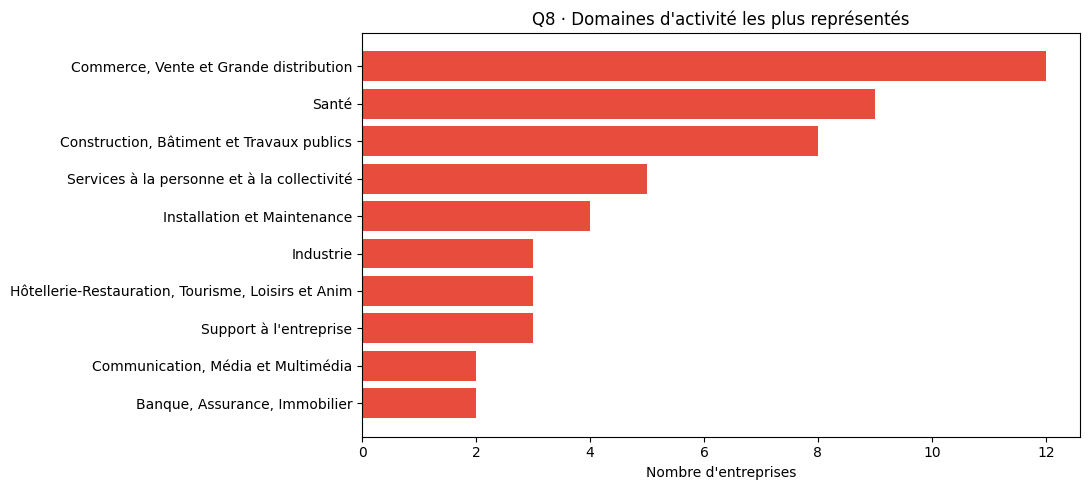

In [41]:
# Q8 — Domaines d'activité
rows = cypher("""
    MATCH (e:Ent)-[:IN_DOMAIN]->(d:Domain)
    RETURN d.label AS domaine, count(e) AS nb_entreprises
    ORDER BY nb_entreprises DESC LIMIT 10
""")
df = pd.DataFrame(rows)
df['domaine'] = df['domaine'].str[:50]
fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(df['domaine'][::-1], df['nb_entreprises'][::-1], color='#e74c3c')
ax.set_xlabel("Nombre d'entreprises")
ax.set_title("Q8 · Domaines d'activité les plus représentés")
plt.tight_layout()
plt.savefig('exports/q8_domaines_activite.png', dpi=150, bbox_inches='tight')
plt.show()

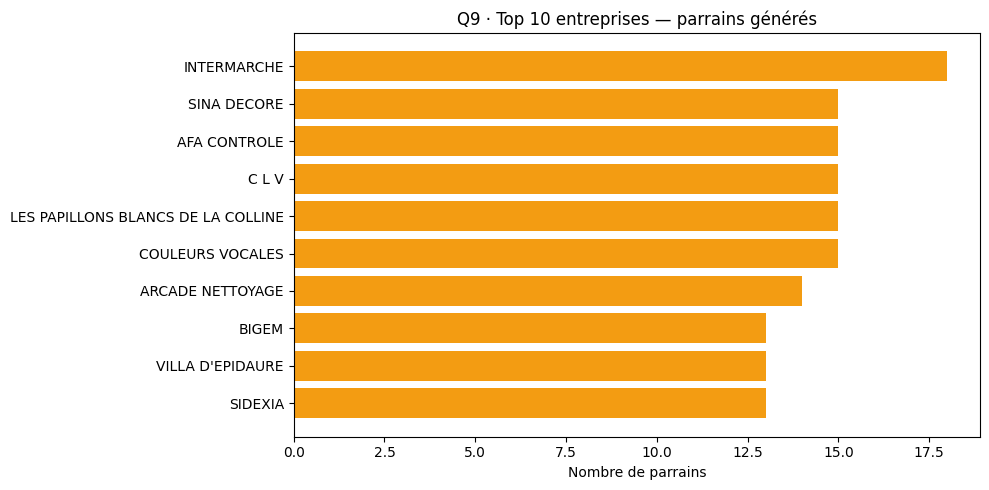

In [42]:
# Q9 — Top entreprises générant le plus de parrains
rows = cypher("""
    MATCH (u:Usr)-[:WORKS_AT]->(e:Ent)
    MATCH (u)-[:SPONSORED]->(:Usr)
    RETURN e.nom AS entreprise, count(DISTINCT u) AS nb_parrains
    ORDER BY nb_parrains DESC LIMIT 10
""")
df = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(df['entreprise'][::-1], df['nb_parrains'][::-1], color='#f39c12')
ax.set_xlabel('Nombre de parrains')
ax.set_title('Q9 · Top 10 entreprises — parrains générés')
plt.tight_layout()
plt.savefig('exports/q9_top_entreprises_parrains.png', dpi=150, bbox_inches='tight')
plt.show()

| Magasin               |   Abonnés (≤ 4 km) |
|:----------------------|-------------------:|
| Mamion Miam           |                225 |
| Mamion Miam, Rueil    |                110 |
| Mamion Miam, Chaville |                152 |
| Mamion Miam, Bagneux  |                194 |


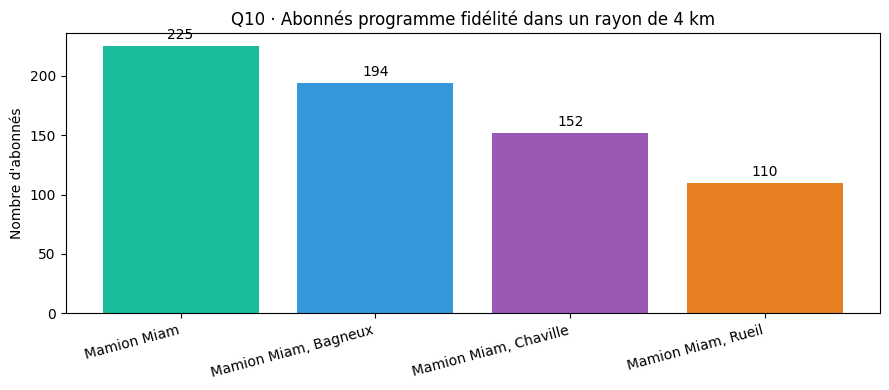

In [43]:
# Q10 — Abonnés dans un rayon de 4 km par magasin
shops = list(db.shops.find({}, {'id': 1, 'name': 1, 'lat': 1, 'lng': 1, '_id': 0}))
results = []
for shop in shops:
    count = db.clients.count_documents({
        'location': {
            '$geoWithin': {
                '$centerSphere': [
                    [float(shop['lng']), float(shop['lat'])],
                    4000 / 6378137
                ]
            }
        }
    })
    results.append({'Magasin': shop['name'], 'Abonnés (≤ 4 km)': count})

print(tabulate(results, headers='keys', tablefmt='pipe'))

df = pd.DataFrame(results).sort_values('Abonnés (≤ 4 km)', ascending=False)
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(df['Magasin'], df['Abonnés (≤ 4 km)'], color=['#1abc9c', '#3498db', '#9b59b6', '#e67e22'])
ax.bar_label(bars, padding=3)
ax.set_ylabel("Nombre d'abonnés")
ax.set_title('Q10 · Abonnés programme fidélité dans un rayon de 4 km')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('exports/q10_abonnes_par_magasin.png', dpi=150, bbox_inches='tight')
plt.show()

In [44]:
driver.close()
mongo.close()
print('Connexions fermées.')

Connexions fermées.
